# ANTAM Gold Price MLOps
## Sistem Peramalan Harga Emas ANTAM dengan Machine Learning Operations

**Dataset**: ANTAM Historical Gold Price  
**Source**: https://www.kaggle.com/datasets/garethharrison/antam-historical-gold-price  
**Periode Data**: 2010-01-04 hingga 2025-10-07  
**Mata Uang**: IDR (Indonesian Rupiah)

### Tujuan Project
- Menganalisis tren harga emas ANTAM historis
- Membangun model forecasting time series
- Mengimplementasikan MLOps pipeline
- Monitoring dan evaluasi model secara berkala

## 1. Setup Kaggle API & Download Dataset

### Langkah-langkah Setup:
1. **Install Kaggle CLI**: `pip install kaggle`
2. **Setup Credentials**: 
   - Buka https://www.kaggle.com/settings/account
   - Klik "Create New API Token"
   - File `kaggle.json` akan terdownload
   - Letakkan di `~/.kaggle/kaggle.json` atau `C:\Users\YourUsername\.kaggle\kaggle.json` (Windows)
3. **Set Permissions**: `chmod 600 ~/.kaggle/kaggle.json` (Linux/Mac)

In [10]:
"""
Setup dan Install Dependencies
Uncomment baris dibawah jika library belum terinstall
"""

# Uncomment untuk install dependencies
# !pip install kaggle pandas numpy matplotlib seaborn plotly scikit-learn tensorflow prophet statsmodels

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Data processing
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistics & ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration
import json
from pathlib import Path

print("✓ All libraries imported successfully!")
print(f"Python Version: {sys.version}")
print(f"Working Directory: {os.getcwd()}")

✓ All libraries imported successfully!
Python Version: 3.11.1 (tags/v3.11.1:a7a450f, Dec  6 2022, 19:58:39) [MSC v.1934 64 bit (AMD64)]
Working Directory: c:\Users\ASUS\Documents\PyML\PythonMLPart2-1


In [11]:
"""
Download Dataset dari Kaggle
Pastikan Kaggle API sudah dikonfigurasi terlebih dahulu!
"""

# Uncomment baris dibawah untuk download dataset
# !kaggle datasets download -d garethharrison/antam-historical-gold-price

# Mengecek apakah file sudah ada
data_dir = Path("./data")
data_dir.mkdir(exist_ok=True)

csv_file = data_dir / "Antam_historical_gold_prices.csv"

if csv_file.exists():
    print(f"✓ Dataset ditemukan: {csv_file}")
    file_size = csv_file.stat().st_size / (1024 * 1024)  # Convert to MB
    print(f"  Ukuran file: {file_size:.2f} MB")
else:
    print(f"⚠ Dataset belum ditemukan di {csv_file}")
    print("Silakan:")
    print("1. Uncomment dan jalankan command: !kaggle datasets download -d garethharrison/antam-historical-gold-price")
    print("2. Atau extract file zip ke folder 'data'")

✓ Dataset ditemukan: data\Antam_historical_gold_prices.csv
  Ukuran file: 0.20 MB


## 2. Load & Explore Data

In [12]:
"""
Load dan explore data ANTAM Gold Price
"""

csv_file = Path("./data/Antam_historical_gold_prices.csv")

if csv_file.exists():
    # Load data
    df = pd.read_csv(csv_file)
    
    # Display basic info
    print("=" * 60)
    print("DATASET INFORMATION")
    print("=" * 60)
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nData Types:\n{df.dtypes}")
    
    # Display first few rows
    print("\n" + "=" * 60)
    print("FIRST 5 ROWS")
    print("=" * 60)
    print(df.head())
    
    # Display last few rows
    print("\n" + "=" * 60)
    print("LAST 5 ROWS")
    print("=" * 60)
    print(df.tail())
    
    # Statistics
    print("\n" + "=" * 60)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 60)
    print(df.describe())
    
    # Missing values
    print("\n" + "=" * 60)
    print("MISSING VALUES")
    print("=" * 60)
    print(df.isnull().sum())
else:
    print("⚠ File CSV tidak ditemukan. Silakan download dataset terlebih dahulu!")

DATASET INFORMATION

Shape: (4893, 3)

Columns: ['Time (ms)', 'Gold Price', 'Date']

Data Types:
Time (ms)     int64
Gold Price    int64
Date            str
dtype: object

FIRST 5 ROWS
       Time (ms)  Gold Price                 Date
0  1262596020000      408000  2010-01-04 09:07:00
1  1262683680000      410000  2010-01-05 09:28:00
2  1262761260000      410000  2010-01-06 07:01:00
3  1262857500000      412000  2010-01-07 09:45:00
4  1262943420000      410000  2010-01-08 09:37:00

LAST 5 ROWS
          Time (ms)  Gold Price                 Date
4888  1763454309000     2322000  2025-11-18 08:25:09
4889  1763454310000     2322000  2025-11-18 08:25:10
4890  1763454311000     2322000  2025-11-18 08:25:11
4891  1763541343000     2343000  2025-11-19 08:35:43
4892  1763628635000     2364000  2025-11-20 08:50:35

DESCRIPTIVE STATISTICS
          Time (ms)    Gold Price
count  4.893000e+03  4.893000e+03
mean   1.533083e+12  8.520455e+05
std    1.447581e+11  3.988312e+05
min    1.262596e+12  3.9

## 3. Data Preprocessing & Preparation

In [13]:
"""
Data Preprocessing
Membersihkan dan mempersiapkan data untuk modeling
"""

csv_file = Path("./data/Antam_historical_gold_prices.csv")

if csv_file.exists():
    df = pd.read_csv(csv_file)
    
    # Create a copy for processing
    df_processed = df.copy()
    
    # 1. Handle missing values
    print("Step 1: Handle Missing Values")
    print(f"Missing values before: {df_processed.isnull().sum().sum()}")
    df_processed = df_processed.dropna()
    print(f"Missing values after: {df_processed.isnull().sum().sum()}")
    print(f"Rows retained: {len(df_processed)} / {len(df)}")
    
    # 2. Parse and convert timestamp
    print("\nStep 2: Convert Timestamp")
    if 'Time (ms)' in df_processed.columns:
        df_processed['datetime'] = pd.to_datetime(df_processed['Time (ms)'], unit='ms')
        df_processed = df_processed.sort_values('datetime')
        print(f"Date range: {df_processed['datetime'].min()} to {df_processed['datetime'].max()}")
    
    # 3. Extract features
    print("\nStep 3: Extract Time Features")
    if 'datetime' in df_processed.columns:
        df_processed['year'] = df_processed['datetime'].dt.year
        df_processed['month'] = df_processed['datetime'].dt.month
        df_processed['day'] = df_processed['datetime'].dt.day
        df_processed['weekday'] = df_processed['datetime'].dt.weekday
        df_processed['quarter'] = df_processed['datetime'].dt.quarter
    
    # 4. Calculate technical indicators
    print("\nStep 4: Calculate Technical Indicators")
    if 'Gold Price' in df_processed.columns:
        df_processed['MA_7'] = df_processed['Gold Price'].rolling(window=7).mean()
        df_processed['MA_30'] = df_processed['Gold Price'].rolling(window=30).mean()
        df_processed['MA_90'] = df_processed['Gold Price'].rolling(window=90).mean()
        
        # Daily returns
        df_processed['daily_return'] = df_processed['Gold Price'].pct_change()
        
        # Volatility (30-day rolling std)
        df_processed['volatility'] = df_processed['daily_return'].rolling(window=30).std()
    
    # 5. Remove rows with NaN from rolling calculations
    df_processed = df_processed.dropna()
    
    print(f"\nFinal dataset shape: {df_processed.shape}")
    print(f"\nCleaned data sample:")
    print(df_processed[['datetime', 'Gold Price', 'MA_7', 'MA_30', 'daily_return', 'volatility']].head(10))
    
    # Save processed data
    processed_file = Path("./data/data_processed.csv")
    df_processed.to_csv(processed_file, index=False)
    print(f"\n✓ Processed data saved to: {processed_file}")
else:
    print("⚠ Raw data tidak ditemukan!")

Step 1: Handle Missing Values
Missing values before: 0
Missing values after: 0
Rows retained: 4893 / 4893

Step 2: Convert Timestamp
Date range: 2010-01-04 09:07:00 to 2025-11-20 08:50:35

Step 3: Extract Time Features

Step 4: Calculate Technical Indicators

Final dataset shape: (4804, 14)

Cleaned data sample:
              datetime  Gold Price           MA_7          MA_30  \
89 2010-05-10 09:00:00      423000  415857.142857  404566.666667   
90 2010-05-10 12:38:00      417000  417142.857143  405233.333333   
91 2010-05-11 07:54:00      417000  418857.142857  405833.333333   
92 2010-05-12 09:09:00      424000  420714.285714  406666.666667   
93 2010-05-14 09:07:00      426000  421571.428571  407566.666667   
94 2010-05-17 08:36:00      429000  422571.428571  408566.666667   
95 2010-05-18 08:09:00      426000  423142.857143  409400.000000   
96 2010-05-19 08:30:00      425000  423428.571429  410133.333333   
97 2010-05-20 09:18:00      417000  423428.571429  410433.333333   
98 201

## 4. Exploratory Data Analysis & Visualization

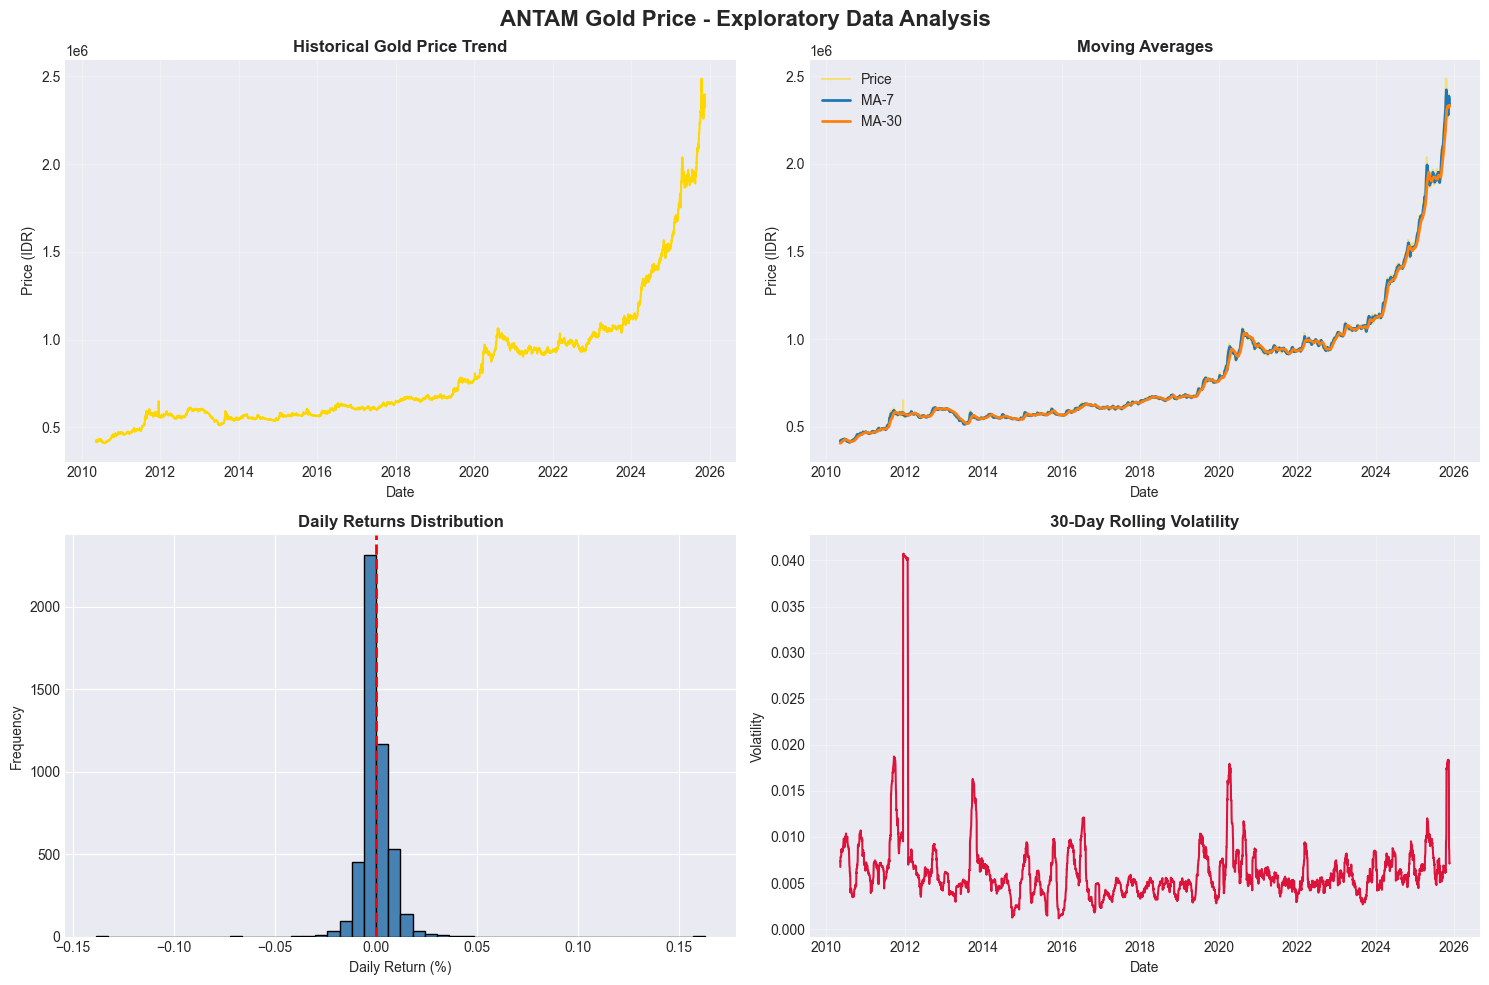

✓ Visualization saved to: ./data/eda_analysis.png

SUMMARY STATISTICS
Total records: 4,804
Date range: 2010-05-10 to 2025-11-20

Gold Price Statistics (IDR):
  Minimum: 409,000
  Maximum: 2,487,000
  Mean: 860,359
  Median: 672,000
  Std Dev: 397,760

Daily Return Statistics:
  Mean: 0.000385
  Std Dev: 0.007299
  Min: -0.138462
  Max: 0.162791


In [14]:
"""
Visualisasi dan Analisis Data
"""

processed_file = Path("./data/data_processed.csv")

if processed_file.exists():
    df = pd.read_csv(processed_file)
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # Set matplotlib style
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('ANTAM Gold Price - Exploratory Data Analysis', fontsize=16, fontweight='bold')
    
    # 1. Time series plot
    axes[0, 0].plot(df['datetime'], df['Gold Price'], linewidth=1.5, color='gold')
    axes[0, 0].set_title('Historical Gold Price Trend', fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Price (IDR)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Moving averages
    axes[0, 1].plot(df['datetime'], df['Gold Price'], label='Price', alpha=0.5, color='gold')
    axes[0, 1].plot(df['datetime'], df['MA_7'], label='MA-7', linewidth=2)
    axes[0, 1].plot(df['datetime'], df['MA_30'], label='MA-30', linewidth=2)
    axes[0, 1].set_title('Moving Averages', fontweight='bold')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Price (IDR)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Daily returns distribution
    axes[1, 0].hist(df['daily_return'].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[1, 0].set_title('Daily Returns Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Daily Return (%)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    
    # 4. Volatility trend
    axes[1, 1].plot(df['datetime'], df['volatility'], color='crimson', linewidth=1.5)
    axes[1, 1].set_title('30-Day Rolling Volatility', fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Volatility')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./data/eda_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved to: ./data/eda_analysis.png")
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS")
    print("=" * 60)
    print(f"Total records: {len(df):,}")
    print(f"Date range: {df['datetime'].min().date()} to {df['datetime'].max().date()}")
    print(f"\nGold Price Statistics (IDR):")
    print(f"  Minimum: {df['Gold Price'].min():,.0f}")
    print(f"  Maximum: {df['Gold Price'].max():,.0f}")
    print(f"  Mean: {df['Gold Price'].mean():,.0f}")
    print(f"  Median: {df['Gold Price'].median():,.0f}")
    print(f"  Std Dev: {df['Gold Price'].std():,.0f}")
    print(f"\nDaily Return Statistics:")
    print(f"  Mean: {df['daily_return'].mean():.6f}")
    print(f"  Std Dev: {df['daily_return'].std():.6f}")
    print(f"  Min: {df['daily_return'].min():.6f}")
    print(f"  Max: {df['daily_return'].max():.6f}")
else:
    print("⚠ Processed data tidak ditemukan!")

## 5. Model Development & Training (Time Series Forecasting)

### Pendekatan:
1. **ARIMA/SARIMA** - Statistical approach
2. **Prophet** - Facebook's time series library
3. **LSTM/RNN** - Deep Learning approach
4. **XGBoost** - Gradient Boosting dengan lagged features

### Train-Test Split Strategy:
- 80% untuk training
- 20% untuk testing (Time Series Split - respecting temporal order)

In [15]:
"""
Train-Test Split dan Baseline Model
"""

processed_file = Path("./data/data_processed.csv")

if processed_file.exists():
    df = pd.read_csv(processed_file)
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # Time series split (80-20)
    split_idx = int(len(df) * 0.8)
    train_df = df[:split_idx].copy()
    test_df = df[split_idx:].copy()
    
    print("=" * 60)
    print("DATA SPLIT")
    print("=" * 60)
    print(f"Total records: {len(df):,}")
    print(f"\nTraining set:")
    print(f"  Rows: {len(train_df):,}")
    print(f"  Date range: {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
    print(f"\nTest set:")
    print(f"  Rows: {len(test_df):,}")
    print(f"  Date range: {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")
    
    # Baseline model: Naive forecast (last value as prediction)
    print("\n" + "=" * 60)
    print("BASELINE MODEL - NAIVE FORECAST")
    print("=" * 60)
    
    # Get the last training value
    last_train_value = train_df['Gold Price'].iloc[-1]
    baseline_predictions = np.full(len(test_df), last_train_value)
    
    # Calculate baseline metrics
    baseline_mse = mean_squared_error(test_df['Gold Price'], baseline_predictions)
    baseline_rmse = np.sqrt(baseline_mse)
    baseline_mae = mean_absolute_error(test_df['Gold Price'], baseline_predictions)
    baseline_mape = np.mean(np.abs((test_df['Gold Price'] - baseline_predictions) / test_df['Gold Price'])) * 100
    
    print(f"MSE:  {baseline_mse:,.2f}")
    print(f"RMSE: {baseline_rmse:,.2f}")
    print(f"MAE:  {baseline_mae:,.2f}")
    print(f"MAPE: {baseline_mape:.2f}%")
    
    # Save train-test split
    train_df.to_csv('./data/train_data.csv', index=False)
    test_df.to_csv('./data/test_data.csv', index=False)
    
    print("\n✓ Train-test data saved!")
    print(f"  - Training: ./data/train_data.csv")
    print(f"  - Testing: ./data/test_data.csv")
    
else:
    print("⚠ Processed data tidak ditemukan!")

DATA SPLIT
Total records: 4,804

Training set:
  Rows: 3,843
  Date range: 2010-05-10 to 2023-05-05

Test set:
  Rows: 961
  Date range: 2023-05-06 to 2025-11-20

BASELINE MODEL - NAIVE FORECAST
MSE:  329,745,759,625.39
RMSE: 574,234.93
MAE:  429,139.44
MAPE: 24.15%

✓ Train-test data saved!
  - Training: ./data/train_data.csv
  - Testing: ./data/test_data.csv


## 6. MLOps Pipeline Framework

### Pipeline Components:
1. **Data Ingestion** - Load data dari Kaggle/Source
2. **Data Validation** - Quality checks
3. **Data Processing** - Cleaning, feature engineering
4. **Model Training** - Multiple models
5. **Model Evaluation** - Metrics & comparison
6. **Model Registry** - Version control
7. **Deployment** - Model serving
8. **Monitoring** - Performance tracking
9. **Retraining Trigger** - Automated retraining

In [16]:
"""
MLOps Utilities - Model Registry & Monitoring
"""

import json
from datetime import datetime

class MLOpsManager:
    """Manager untuk MLOps pipeline"""
    
    def __init__(self, models_dir='./models'):
        self.models_dir = Path(models_dir)
        self.models_dir.mkdir(exist_ok=True)
        self.registry_file = self.models_dir / 'model_registry.json'
        self.log_file = self.models_dir / 'training_log.json'
        
    def save_metrics(self, model_name, metrics, model_type='baseline'):
        """Simpan metrics model"""
        timestamp = datetime.now().isoformat()
        
        metrics_data = {
            'timestamp': timestamp,
            'model_name': model_name,
            'model_type': model_type,
            'metrics': metrics
        }
        
        # Load existing log
        logs = []
        if self.log_file.exists():
            with open(self.log_file, 'r') as f:
                logs = json.load(f)
        
        logs.append(metrics_data)
        
        # Save updated log
        with open(self.log_file, 'w') as f:
            json.dump(logs, f, indent=2)
        
        return metrics_data
    
    def get_best_model(self):
        """Dapatkan model dengan performa terbaik"""
        if not self.log_file.exists():
            return None
        
        with open(self.log_file, 'r') as f:
            logs = json.load(f)
        
        if not logs:
            return None
        
        # Sort by RMSE (ascending)
        best_model = min(logs, key=lambda x: x['metrics'].get('rmse', float('inf')))
        return best_model
    
    def print_model_comparison(self):
        """Tampilkan perbandingan model"""
        if not self.log_file.exists():
            print("Tidak ada model yang tercatat")
            return
        
        with open(self.log_file, 'r') as f:
            logs = json.load(f)
        
        print("\n" + "=" * 80)
        print("MODEL COMPARISON")
        print("=" * 80)
        print(f"{'Model Name':<20} {'Type':<15} {'RMSE':<15} {'MAE':<15} {'MAPE(%)':<15}")
        print("-" * 80)
        
        for log in sorted(logs, key=lambda x: x['metrics'].get('rmse', float('inf'))):
            metrics = log['metrics']
            print(f"{log['model_name']:<20} {log['model_type']:<15} "
                  f"{metrics.get('rmse', 0):<15.2f} {metrics.get('mae', 0):<15.2f} "
                  f"{metrics.get('mape', 0):<15.2f}")

# Inisialisasi MLOps Manager
mlops = MLOpsManager()

# Log baseline model
baseline_metrics = {
    'rmse': baseline_rmse,
    'mae': baseline_mae,
    'mape': baseline_mape,
    'mse': baseline_mse
}

mlops.save_metrics('baseline_naive', baseline_metrics, 'baseline')
print("✓ Baseline model metrics saved to registry")
mlops.print_model_comparison()

✓ Baseline model metrics saved to registry

MODEL COMPARISON
Model Name           Type            RMSE            MAE             MAPE(%)        
--------------------------------------------------------------------------------
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
prophet_model        prophet         544813.53       416071.14       23.73          
arima_5_1_0          arima           573979.52       428892.81       24.13          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline

### Model 1: ARIMA (AutoRegressive Integrated Moving Average)
Menggunakan library `statsmodels` untuk membuat model ARIMA. Mengikuti template MLOps pipeline yang ada.

ARIMA MODEL TRAINING (ROLLING FORECAST)
Melatih model ARIMA awal dan melakukan walk-forward validation...
Proses ini mensimulasikan penerapan model secara harian (1-step ahead forecast).
Melatih model inisial...
✓ Model inisial berhasil dilatih!
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0661      0.002    -28.964      0.000      -0.071      -0.062
ar.L2         -0.0202      0.007     -3.014      0.003      -0.033      -0.007
ar.L3          0.0045      0.008      0.543      0.587      -0.012       0.021
ar.L4          0.0103      0.011      0.936      0.349      -0.011       0.032
ar.L5          0.0062      0.012      0.534      0.594      -0.017       0.029
sigma2      2.543e+07    1.6e-10   1.59e+17      0.000    2.54e+07    2.54e+07

Melakukan proses rolling predictions (Walk-Forward Validation)...
Model akan diprediksi harian, dan menambahkan data real

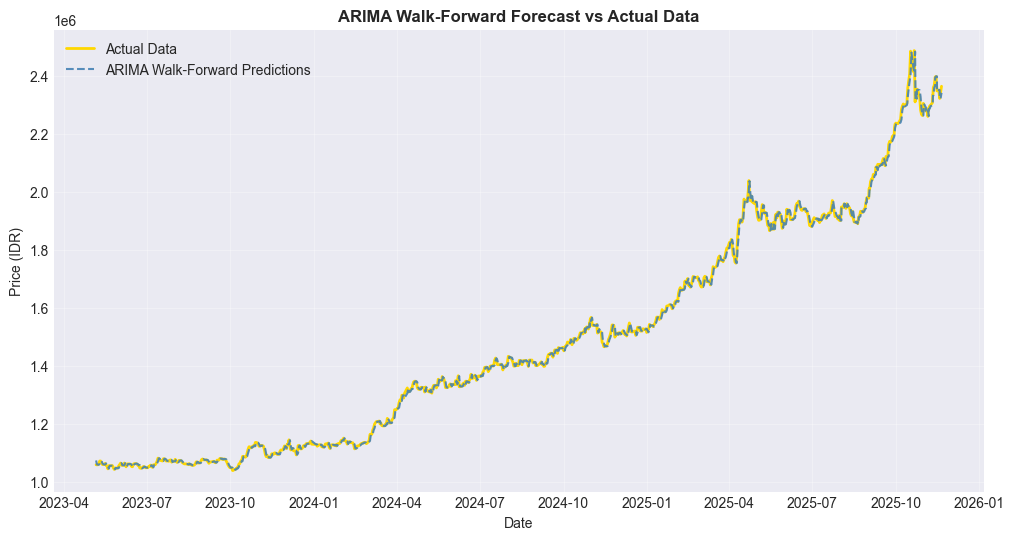

✓ Visualization saved to: ./data/arima_forecast.png

✓ ARIMA rolling model metrics saved to registry

MODEL COMPARISON
Model Name           Type            RMSE            MAE             MAPE(%)        
--------------------------------------------------------------------------------
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
prophet_model        prophet         544813.53       416071.14       23.73          
arima_5_1_0          arima           573979.52       428892.81       24.13          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline      

In [17]:
"""
ARIMA Model Training dan Evaluation (Walk-Forward / Rolling Forecast)
Untuk Time Series panjang, memprediksi terlalu jauh ke depan dengan ARIMA akan menghasilkan garis lurus yang statis.
Itulah mengapa prediksi terihat jauh dari aktual.
Solusinya adalah menggunakan metode Walk-Forward Validation, memprediksi 1 langkah (hari) ke depan, 
lalu memasukkan data aktual terbaru setiap harinya dan mengulang prediksi.
"""

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

processed_file = Path("./data/data_processed.csv")

if processed_file.exists():
    print("=" * 60)
    print("ARIMA MODEL TRAINING (ROLLING FORECAST)")
    print("=" * 60)
    
    # Load the split data
    train_df = pd.read_csv('./data/train_data.csv')
    test_df = pd.read_csv('./data/test_data.csv')
    train_df['datetime'] = pd.to_datetime(train_df['datetime'])
    test_df['datetime'] = pd.to_datetime(test_df['datetime'])
    
    train_data = train_df['Gold Price'].values
    test_data = test_df['Gold Price'].values
    
    print("Melatih model ARIMA awal dan melakukan walk-forward validation...")
    print("Proses ini mensimulasikan penerapan model secara harian (1-step ahead forecast).")
    
    try:
        history = list(train_data)
        predictions = []
        
        print("Melatih model inisial...")
        # Fit model awal
        model = ARIMA(history, order=(5,1,0))
        model_fit = model.fit()
        
        print("✓ Model inisial berhasil dilatih!")
        print(model_fit.summary().tables[1])
        print("\nMelakukan proses rolling predictions (Walk-Forward Validation)...")
        print("Model akan diprediksi harian, dan menambahkan data real terbaru setiap hari ke history.")
        
        for t in range(len(test_data)):
            # Prediksi 1 hari ke depan berdasarkan state saat ini
            # forecast(1) menghasilkan prediksi untuk hari berikutnya
            yhat = model_fit.forecast(steps=1)[0]
            predictions.append(yhat)
            
            # Observasi data aktual harian yang "terjadi"
            obs = test_data[t]
            
            # Update history dengan data observasi terbaru tanpa re-training keseluruhan (lebih cepat)
            model_fit = model_fit.append([obs], refit=False)
            
            if (t+1) % 100 == 0:
                print(f"  Step {t+1}/{len(test_data)} iterasi prediksi selesai")
        
        # Convert to numpy array for metrics calculation
        predictions = np.array(predictions)
        
        # Calculate evaluation metrics
        arima_mse = mean_squared_error(test_data, predictions)
        arima_rmse = np.sqrt(arima_mse)
        arima_mae = mean_absolute_error(test_data, predictions)
        arima_mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100
        
        print(f"\nEvaluation Metrics:")
        print(f"MSE:  {arima_mse:,.2f}")
        print(f"RMSE: {arima_rmse:,.2f}")
        print(f"MAE:  {arima_mae:,.2f}")
        print(f"MAPE: {arima_mape:.2f}%")
        
        # Visualize predictions
        plt.figure(figsize=(12, 6))
        plt.plot(test_df['datetime'], test_data, label='Actual Data', color='gold', linewidth=2)
        # Tambahkan prediksi walk-forward dengan garis putus-putus atau alfa agar terlihat
        plt.plot(test_df['datetime'], predictions, label='ARIMA Walk-Forward Predictions', color='steelblue', alpha=0.9, linestyle='--')
        plt.title('ARIMA Walk-Forward Forecast vs Actual Data', fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Price (IDR)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig('./data/arima_forecast.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Visualization saved to: ./data/arima_forecast.png")
        
        # Save metrics to MLOps Registry
        arima_metrics = {
            'rmse': arima_rmse,
            'mae': arima_mae,
            'mape': arima_mape,
            'mse': arima_mse
        }
        
        mlops.save_metrics('arima_5_1_0_rolling', arima_metrics, 'arima')
        print("\n✓ ARIMA rolling model metrics saved to registry")
        mlops.print_model_comparison()
        
    except Exception as e:
        import traceback
        print(f"Error saat melatih model ARIMA: {str(e)}")
        traceback.print_exc()
else:
    print("⚠ Data belum disiapkan. Jalankan cell Data Preprocessing terlebih dahulu!")


### Model 2: Facebook Prophet
Menggunakan library `prophet` untuk membuat model forecasting. Mengikuti template MLOps pipeline yang ada.

FACEBOOK PROPHET MODEL TRAINING
Melatih model Prophet...


16:28:17 - cmdstanpy - INFO - Chain [1] start processing
16:28:28 - cmdstanpy - INFO - Chain [1] done processing


✓ Model Prophet berhasil dilatih!

Melakukan prediksi pada data pengujian (Test Data)...

Evaluation Metrics:
MSE:  296,821,787,852.54
RMSE: 544,813.53
MAE:  416,071.14
MAPE: 23.73%


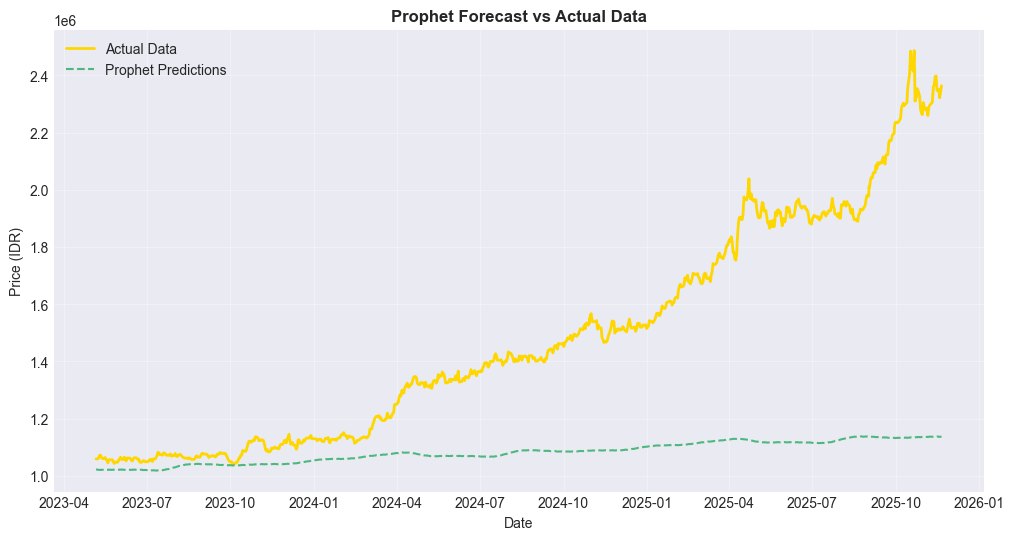

✓ Visualization saved to: ./data/prophet_forecast.png

✓ Prophet model metrics saved to registry

MODEL COMPARISON
Model Name           Type            RMSE            MAE             MAPE(%)        
--------------------------------------------------------------------------------
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
arima_5_1_0_rolling  arima           13030.11        7728.42         0.48           
prophet_model        prophet         544813.53       416071.14       23.73          
prophet_model        prophet         544813.53       416071.14       23.73          
arima_5_1_0          arima           573979.52       428892.81       24.13          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        574234.93       429139.44       24.15          
baseline_naive       baseline        57

In [18]:
"""
Facebook Prophet Model Training dan Evaluation
Prophet secara inheren baik untuk data dengan musiman kuat dan hari libur.
Sangat handal untuk data deret waktu seperti harga emas harian.
Berbeda dengan ARIMA, kita dapat membuat model tunggal dan memprediksi ke depan
karena kemampuannya menangani tren dan musiman, tapi kita juga bisa 
mengevaluasinya.
"""

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

processed_file = Path("./data/data_processed.csv")

if processed_file.exists():
    print("=" * 60)
    print("FACEBOOK PROPHET MODEL TRAINING")
    print("=" * 60)
    
    # Load the split data
    train_df = pd.read_csv('./data/train_data.csv')
    test_df = pd.read_csv('./data/test_data.csv')
    train_df['datetime'] = pd.to_datetime(train_df['datetime'])
    test_df['datetime'] = pd.to_datetime(test_df['datetime'])
    
    # Prophet requires specific column names: 'ds' (datetime) and 'y' (target)
    prophet_train = train_df[['datetime', 'Gold Price']].rename(columns={'datetime': 'ds', 'Gold Price': 'y'})
    prophet_test = test_df[['datetime', 'Gold Price']].rename(columns={'datetime': 'ds', 'Gold Price': 'y'})
    
    print("Melatih model Prophet...")
    
    try:
        # Inisialisasi dan fit model Prophet
        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=True,
            changepoint_prior_scale=0.05
        )
        model.fit(prophet_train)
        print("✓ Model Prophet berhasil dilatih!")
        
        print("\nMelakukan prediksi pada data pengujian (Test Data)...")
        # Membuat dataframe future untuk diprediksi
        future = test_df[['datetime']].rename(columns={'datetime': 'ds'})
        forecast = model.predict(future)
        
        predictions = forecast['yhat'].values
        test_data = prophet_test['y'].values
        
        # Calculate evaluation metrics
        prophet_mse = mean_squared_error(test_data, predictions)
        prophet_rmse = np.sqrt(prophet_mse)
        prophet_mae = mean_absolute_error(test_data, predictions)
        prophet_mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100
        
        print(f"\nEvaluation Metrics:")
        print(f"MSE:  {prophet_mse:,.2f}")
        print(f"RMSE: {prophet_rmse:,.2f}")
        print(f"MAE:  {prophet_mae:,.2f}")
        print(f"MAPE: {prophet_mape:.2f}%")
        
        # Visualize predictions
        plt.figure(figsize=(12, 6))
        plt.plot(test_df['datetime'], test_data, label='Actual Data', color='gold', linewidth=2)
        plt.plot(test_df['datetime'], predictions, label='Prophet Predictions', color='mediumseagreen', alpha=0.9, linestyle='--')
        plt.title('Prophet Forecast vs Actual Data', fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Price (IDR)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig('./data/prophet_forecast.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Visualization saved to: ./data/prophet_forecast.png")
        
        # Save metrics to MLOps Registry
        prophet_metrics = {
            'rmse': float(prophet_rmse),
            'mae': float(prophet_mae),
            'mape': float(prophet_mape),
            'mse': float(prophet_mse)
        }
        
        mlops.save_metrics('prophet_model', prophet_metrics, 'prophet')
        print("\n✓ Prophet model metrics saved to registry")
        mlops.print_model_comparison()
        
    except Exception as e:
        import traceback
        print(f"Error saat melatih model Prophet: {str(e)}")
        traceback.print_exc()
else:
    print("⚠ Data belum disiapkan. Jalankan cell Data Preprocessing terlebih dahulu!")


## 7. Next Steps & Roadmap

### Phase 1: Baseline ✓
- [x] Data loading and exploration
- [x] Basic preprocessing
- [x] Baseline model (Naive Forecast)
- [x] MLOps framework setup

### Phase 2: Advanced Models (TODO)
- [x] ARIMA/SARIMA model
- [x] Facebook Prophet model
- [ ] XGBoost dengan feature engineering
- [ ] LSTM neural network
- [ ] Model comparison & selection

### Phase 3: Production & Deployment (TODO)
- [ ] Model versioning & registry
- [ ] API development (FastAPI/Flask)
- [ ] Docker containerization
- [ ] CI/CD pipeline setup
- [ ] Cloud deployment (AWS/GCP/Azure)

### Phase 4: Monitoring & Maintenance (TODO)
- [ ] Performance monitoring dashboard
- [ ] Data drift detection
- [ ] Model retraining trigger
- [ ] Alerting system
- [ ] A/B testing framework

## 8. Important Notes

### Data Source
- **Dataset**: ANTAM Historical Gold Price
- **URL**: https://www.kaggle.com/datasets/garethharrison/antam-historical-gold-price
- **License**: MIT
- **Update Frequency**: Weekly
- **Coverage**: 2010-01-04 hingga 2025-10-07

### Technical Stack
- **Data Processing**: Pandas, NumPy
- **Visualization**: Matplotlib, Seaborn, Plotly
- **ML Libraries**: scikit-learn, Prophet, TensorFlow/Keras, XGBoost
- **Time Series**: statsmodels
- **MLOps**: Model Registry, Training Logs

### Folder Structure
```
ANTAM_Gold_Price_MLOps/
├── data/
│   ├── Antam_historical_gold_prices.csv     (Raw data)
│   ├── data_processed.csv                    (Processed data)
│   ├── train_data.csv                        (80% training set)
│   ├── test_data.csv                         (20% test set)
│   └── eda_analysis.png                      (EDA visualizations)
├── models/
│   ├── model_registry.json                   (Model metadata)
│   └── training_log.json                     (Training logs)
└── ANTAM_Gold_Price_MLOps.ipynb             (This notebook)
```

### Key Metrics
- **RMSE**: Root Mean Squared Error (lebih sensitif terhadap outliers)
- **MAE**: Mean Absolute Error (lebih robust)
- **MAPE**: Mean Absolute Percentage Error (persentase error)

### Tips untuk Development Lebih Lanjut
1. Gunakan time series cross-validation (tidak random split)
2. Monitor data drift dan concept drift
3. Implement proper error handling dan logging
4. Dokumentasi code yang baik
5. Unit testing untuk critical functions